# Echo cancellers head to head

Four complete echo cancellers, identical signals, one meter:

| system | what it is | license |
|---|---|---|
| **WebRTC AEC3** | the canceller deployed in Chrome: linear filter bank + a deliberately aggressive residual suppressor, tuned for telephony | BSD-3 |
| **DTLN-aec 512** | end-to-end neural AEC (Westhausen & Meyer, ICASSP 2021; 3rd place, Microsoft AEC Challenge), 10.4M parameters | MIT code+weights; weights trained on mixed-license data — benchmark-only |
| **MuTap classical** | `mutap.aec~ @postfilter 1`, as the ITU battery certifies it: FD-Kalman canceller + coherence-driven residual suppressor ([`postfilter.h`](../include/mutap/postfilter.h)) | MIT |
| **MuTap learned** | `mutap.aec~ @postfilter 2`: the same linear-canceller family with the post-filter replaced by a ~52k-parameter trained band-gain network ([`nn_suppressor.h`](../include/mutap/nn_suppressor.h)), trained on clean-licensed data by [`tools/ml`](../tools/ml) | MIT (incl. weights) |

The comparison runs in **two parts**, because two constraints pull in
opposite directions. DTLN-aec's models are inherently 16 kHz, so a
comparison that includes it must run at the benchmark geometry
(16 kHz, block 64) — that is Part 1, using the **v1 prototype** of
MuTap's learned engine (trained at that geometry, before the training
recipe matured). `mutap.aec~` ships at 48 kHz / block 256 with the
**v2 model** trained natively there — that is Part 2, without DTLN,
with every MuTap engine running its real deployment path (the C ABI
chain). One engine identity keeps one color throughout; v1 and v2 are
generations of the same aqua "MuTap learned" engine, and the text says
which is on stage.

Protocol per scenario (the test rig's, [`test_aec.cpp`](../tests/test_aec.cpp)):
**converge** (far end only) → **double-talk** (near end at 0 dB) →
**recovery** (far only) → **near-only** (far end silent; a perfect
canceller passes this segment untouched). The meter delay-compensates
every system, and the MuTap engines run with comfort noise and the
receive guard off so it reads signal, not fill. The wider survey
(linear baselines, band-gain heatmaps) is
[`ml_aec_comparison.ipynb`](ml_aec_comparison.ipynb); licensing and the
full result tables are in [`tools/ml/README.md`](../tools/ml/README.md).

In [1]:
import os, pathlib, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(REPO / "tools" / "ml"))
import features, metrics, mutap_ffi, nn, webrtc_aec3

BUILD = REPO / "build-ml"
def _run(cmd):
    r = subprocess.run([str(c) for c in cmd], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout); print(r.stderr, file=sys.stderr)
        raise RuntimeError("command failed")

if not (BUILD / "tools/ml/aec_scenario_dump").exists():
    _run(["cmake", "-S", REPO, "-B", BUILD, "-DCMAKE_BUILD_TYPE=Release",
          "-DMUTAP_BUILD_CAPI=ON", "-DMUTAP_BUILD_ML_TOOLS=ON", "-DMUTAP_BUILD_TESTS=OFF"])
    _run(["cmake", "--build", BUILD, "--target", "mutap_capi", "aec_scenario_dump", "-j"])
lib = mutap_ffi.load_library(BUILD)
V1_WEIGHTS = REPO / "tools/ml/pretrained/suppressor_v1.munn"
V2_WEIGHTS = REPO / "tools/ml/pretrained/suppressor_v2_48k.munn"
AEC3_BIN = pathlib.Path(os.environ.get("MUTAP_WEBRTC_AEC3_BIN",
                                       BUILD / "tools/ml/webrtc_aec3_infer"))
LIBRI = os.environ.get("MUTAP_LIBRISPEECH",
                       "/tmp/claude-0/-home-user/425f09f3-c52d-5603-aaf0-eebeab94b576/scratchpad/speech/LibriSpeech/dev-clean-2")
HAVE_AEC3, HAVE_SPEECH = AEC3_BIN.exists(), pathlib.Path(LIBRI).exists()

BLOCK, PARTS = 64, 16
# Fixed identity -> color, never reassigned (categorical palette,
# validated colorblind-safe in this order): AEC3 blue, MuTap classical
# orange, MuTap learned aqua (v1 and v2 alike), DTLN yellow.
SYSTEMS = []
if HAVE_AEC3:
    SYSTEMS.append(("WebRTC AEC3", "#2a78d6",
                    lambda: webrtc_aec3.WebRtcAec3(AEC3_BIN)))
else:
    print("webrtc_aec3_infer absent — AEC3 rows skipped (build recipe: tools/ml/README.md)")
SYSTEMS += [
    ("MuTap classical", "#eb6834",
     lambda: mutap_ffi.AecChain(lib, BLOCK, PARTS, 16000.0)),
    ("MuTap learned (v1)", "#1baf7a",
     lambda: nn.KalmanNnSystem(lib, BLOCK, PARTS, str(V1_WEIGHTS))),
]
DTLN_DIR = os.environ.get("MUTAP_DTLN_DIR", "/workspace/breizhn/dtln-aec/pretrained_models")
if pathlib.Path(DTLN_DIR, "dtln_aec_512_1.tflite").exists():
    import dtln_aec
    SYSTEMS.append(("DTLN-aec 512", "#eda100",
                    lambda: dtln_aec.DtlnAec(str(pathlib.Path(DTLN_DIR) / "dtln_aec_512"))))
else:
    print("DTLN models absent — rows skipped (clone github.com/breizhn/DTLN-aec, set MUTAP_DTLN_DIR)")

def run_all(scn):
    out = {}
    for name, color, make in SYSTEMS:
        e = make().process(scn.x, scn.y)
        d = metrics.find_delay(scn, e)
        out[name] = (np.concatenate((e[d:], np.zeros(d))), metrics.measure(scn, e), color)
    return out

def block_power(scn, sig, n, smooth=25):
    p = np.sum(sig[: n - n % scn.block].reshape(-1, scn.block) ** 2, axis=1) / scn.block
    return np.convolve(p, np.ones(smooth) / smooth, mode="same")

def shade_segments(ax, scn, fs=16000, upto=None):
    for segname, (lo, hi) in scn.bounds.items():
        if upto and lo >= upto:
            continue
        if segname == "double_talk":
            ax.axvspan(lo / fs, min(hi, upto or hi) / fs, color="0.5", alpha=0.10, lw=0)
        ax.text((lo + min(hi, upto or hi)) / 2 / fs, 1.005, segname.replace("_", " "),
                transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=8, color="0.35")

def style(ax):
    ax.grid(True, axis="y", alpha=0.15)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

## Part 1 — the benchmark geometry (16 kHz), with DTLN-aec

Two views of the same runs, then a scorecard. First the **deployable
view**: send-path level relative to the far-end level — the industry
chart, and the only meter a deployed product could compute itself.
Below the dashed −30 dB line is "echo inaudible enough"; the shaded
band is the double-talk window, where the near-end talker's own speech
*legitimately* raises the trace. That makes the shading a lie detector:
**a system that stays low through it is suppressing the talker**, not
cancelling echo. Real speech pauses, so the trace is gated to
far-end-active spans.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


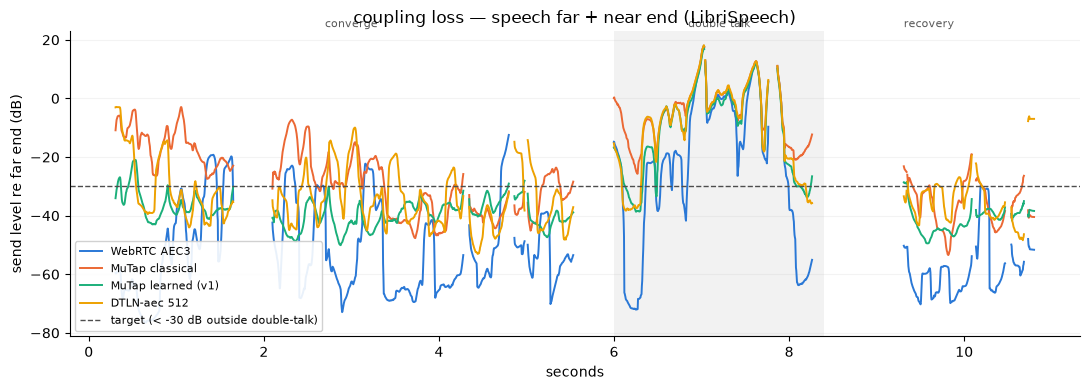

In [2]:
def plot_tclw(scn, results, title, target_db=-30.0, fs=16000):
    n_active = scn.bounds["recovery"][1]
    p_x = block_power(scn, scn.x, n_active)
    active = p_x > 0.05 * np.mean(p_x)
    fig, ax = plt.subplots(figsize=(11, 4.0))
    for name, (e, _, color) in results.items():
        trace = 10 * np.log10(block_power(scn, e, n_active) / (p_x + 1e-12) + 1e-12)
        trace[~active] = np.nan
        t = (np.arange(len(trace)) * scn.block + scn.block / 2) / fs
        ax.plot(t, trace, label=name, color=color, lw=1.4)
    ax.axhline(target_db, color="0.3", ls="--", lw=1,
               label=f"target (< {target_db:.0f} dB outside double-talk)")
    shade_segments(ax, scn, fs, upto=n_active)
    ax.set(xlabel="seconds", ylabel="send level re far end (dB)", title=title)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
    style(ax); fig.tight_layout()

SCEN = REPO / "build-ml" / "nb-scenarios"
def dump(material, seed, room="studio"):
    folder = SCEN / f"{material}-s{seed}-{room}"
    if not (folder / "manifest.json").exists():
        folder.mkdir(parents=True, exist_ok=True)
        _run([BUILD / "tools/ml/aec_scenario_dump", folder, material, seed, room])
    return metrics.Scenario.load(folder)

if HAVE_SPEECH:
    scen_dir = SCEN / "speech"
    if len(list(scen_dir.glob("*/manifest.json"))) < 3:  # count, not existence:
        # another notebook may have generated fewer into the same cache
        _run([sys.executable, REPO / "tools/ml/make_dataset.py", "--corpus", LIBRI,
              "--scenarios", scen_dir, "--examples", "3", "--seed", "7",
              "--build-dir", BUILD])
    speech_scns = [metrics.Scenario.load(p.parent)
                   for p in sorted(scen_dir.glob("*/manifest.json"))]
    speech_res = [run_all(s) for s in speech_scns]
    plot_tclw(speech_scns[0], speech_res[0],
              "coupling loss — speech far + near end (LibriSpeech)")
else:
    print("speech corpus absent — set MUTAP_LIBRISPEECH (openslr.org/31)")

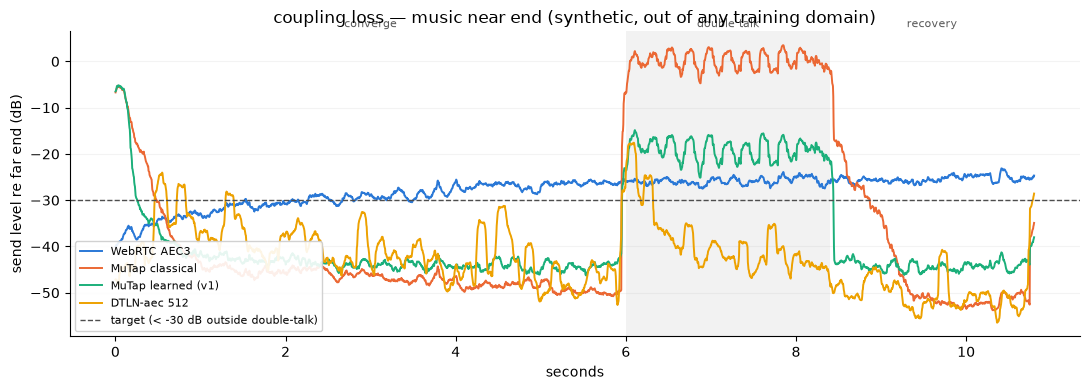

In [3]:
scn_music = dump("music", 2)
res_music = run_all(scn_music)
plot_tclw(scn_music, res_music, "coupling loss — music near end (synthetic, out of any training domain)")

Read the two charts together and the systems separate into
temperaments. On **speech** — every system's best case — all four
converge inside a second and return below the target line immediately
after double-talk: no filter is destroyed by the segment. On **music**
the shading exposes the ML systems: DTLN rides far below the mic level
through the double-talk window, and the v1 learned engine partially
follows — on this meter that looks like winning, but a talker is
playing, so low means *attenuating the program material*. The
classical trace does the honest thing there (rises while the talker
plays, because the talker passes through) and shows its one visible
cost: ~1.5 s to re-deepen after the segment ends.

### The simulator's view: what is actually left

The deployable meter cannot separate "talker, correctly passed" from
"echo, incorrectly leaked". The rig can — it knows the true echo and
the true near end individually — so this second view plots
**everything in the output that should not be there**: residual echo
during the talk segments, damage to the talker in `near_only`.
Perfect = −∞.

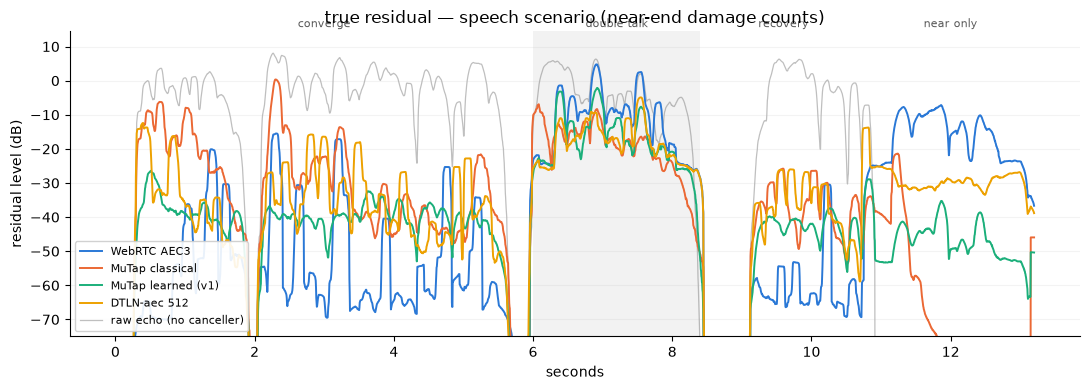

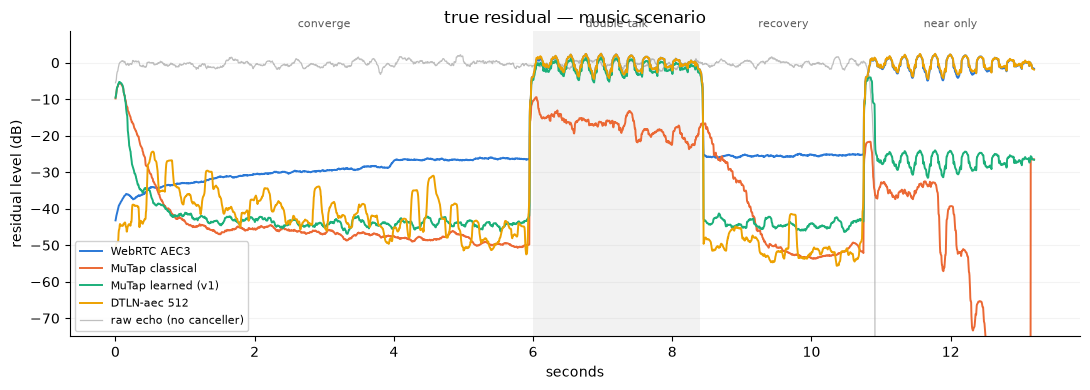

In [4]:
def plot_residual(scn, results, title, fs=16000):
    fig, ax = plt.subplots(figsize=(11, 4.0))
    for name, (e, _, color) in results.items():
        r = e - scn.v
        p = block_power(scn, r, len(r))
        t = (np.arange(len(p)) * scn.block + scn.block / 2) / fs
        ax.plot(t, 10 * np.log10(p + 1e-12), label=name, color=color, lw=1.4)
    p_mic = block_power(scn, scn.y - scn.v, len(scn.y))
    t = (np.arange(len(p_mic)) * scn.block + scn.block / 2) / fs
    ax.plot(t, 10 * np.log10(p_mic + 1e-12), color="0.75", lw=0.9, zorder=0,
            label="raw echo (no canceller)")
    shade_segments(ax, scn, fs)
    ax.set(xlabel="seconds", ylabel="residual level (dB)", title=title)
    ax.set_ylim(bottom=-75)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
    style(ax); fig.tight_layout()

if HAVE_SPEECH:
    plot_residual(speech_scns[0], speech_res[0],
                  "true residual — speech scenario (near-end damage counts)")
plot_residual(scn_music, res_music, "true residual — music scenario")

The rightmost segment, `near_only`, is the transparency verdict:
the far end is silent there, so everything above the floor is damage
to the talker. Both MuTap engines drop toward the floor. AEC3 stays
high on both materials — its suppressor keeps working on signal it
cannot explain — and on music DTLN sits at the talker's own level,
which is this notebook's starkest single observation: the talker has
been deleted, not cleaned.

### Scorecard, Part 1

Four numbers per system, in two material groups: medians over the
three speech scenarios, and over the rig's three synthetic materials
(speech-envelope AR, voiced, music — all outside every network's
training data). Single-talk and recovery ERLE measure echo removal
(higher is better); double-talk suppression measures echo removed
*while the talker speaks*; near-end SDR measures talker fidelity
(80 = untouched).


speech (medians):
              system |  stERLE |  dtSUP | recERLE |  neSDR
----------------------------------------------------------
         WebRTC AEC3 |    37.9 |    2.7 |    39.2 |    4.5
     MuTap classical |    30.9 |   17.2 |    34.0 |   38.2
  MuTap learned (v1) |    36.0 |   11.1 |    36.4 |   37.6
        DTLN-aec 512 |    43.4 |   14.2 |    26.3 |   29.3

synthetic (medians):
              system |  stERLE |  dtSUP | recERLE |  neSDR
----------------------------------------------------------
         WebRTC AEC3 |    26.4 |   -0.0 |    25.4 |    8.7
     MuTap classical |    41.9 |   15.0 |    47.5 |   36.1
  MuTap learned (v1) |    43.6 |   -0.1 |    44.2 |   33.2
        DTLN-aec 512 |    40.7 |   -0.1 |    43.4 |    0.1


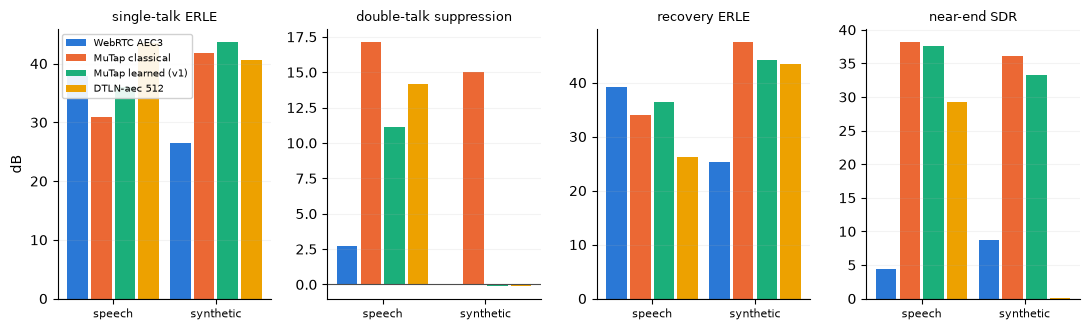

In [5]:
import statistics

def medians(runs, key):
    return {name: statistics.median(r[name][1].as_dict()[key] for r in runs)
            for name, _, _ in SYSTEMS}

synth_scns = [dump(m, 2) for m in ("ar", "voiced", "music")]
synth_res = [run_all(s) for s in synth_scns]

PANELS = [("st_erle_db", "single-talk ERLE"), ("dt_suppression_db", "double-talk suppression"),
          ("rec_erle_db", "recovery ERLE"), ("ne_sdr_db", "near-end SDR")]
GROUPS = [("speech", speech_res if HAVE_SPEECH else []), ("synthetic", synth_res)]
GROUPS = [(g, r) for g, r in GROUPS if r]

fig, axes = plt.subplots(1, len(PANELS), figsize=(11, 3.4), sharey=False)
w = 0.8 / len(SYSTEMS)
for ax, (key, label) in zip(axes, PANELS):
    for si, (name, color, _) in enumerate(SYSTEMS):
        vals = [medians(runs, key)[name] for _, runs in GROUPS]
        xs = np.arange(len(GROUPS)) + (si - (len(SYSTEMS) - 1) / 2) * (w + 0.03)
        ax.bar(xs, vals, width=w, color=color, label=name)
    ax.set_xticks(np.arange(len(GROUPS)), [g for g, _ in GROUPS], fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.axhline(0, color="0.3", lw=0.8)
    style(ax)
axes[0].set_ylabel("dB")
axes[0].legend(loc="upper left", fontsize=7, framealpha=0.9)
fig.tight_layout()

for gname, runs in GROUPS:
    print(f"\n{gname} (medians):")
    hdr = f"{'system':>20} | {'stERLE':>7} | {'dtSUP':>6} | {'recERLE':>7} | {'neSDR':>6}"
    print(hdr); print("-" * len(hdr))
    for name, _, _ in SYSTEMS:
        m = {k: medians(runs, k)[name] for k, _ in PANELS}
        print(f"{name:>20} | {m['st_erle_db']:7.1f} | {m['dt_suppression_db']:6.1f} | "
              f"{m['rec_erle_db']:7.1f} | {m['ne_sdr_db']:6.1f}")

Part 1 in one sentence per system: **DTLN** takes the speech
single-talk ERLE crown and deletes any talker it was not trained on;
**AEC3** removes echo well and ducks every talker, everywhere, to
single-digit SDR (its telephony design choice); **MuTap classical** is
the only system whose double-talk suppression *and* transparency hold
on every material; **MuTap learned (v1)** already beats classical on
speech ERLE at equal transparency, but this early model's double-talk
contribution disappears off-domain — which is exactly what its v2
retraining targets, and Part 2 measures.

## Part 2 — the shipping geometry (48 kHz, block 256)

Part 1's geometry was chosen for DTLN's sake. `mutap.aec~` actually
runs at 48 kHz / block 256, and the learned engine that ships in it
(`@postfilter 2`) is the **v2 model**: trained at that native geometry,
with the off-domain fix in its data — the training near ends mix
speech with the same synthetic families that exposed v1 above. Two
further differences from Part 1, both toward realism: the MuTap
engines here run their real deployment path (the C ABI chain — v1
above was the research prototype composition), and AEC3 runs at
48 kHz. DTLN sits this part out; its models are inherently 16 kHz.

48 kHz speech (medians over 3):
              system |  stERLE |  dtSUP | recERLE |  neSDR
----------------------------------------------------------
         WebRTC AEC3 |    42.3 |    3.9 |    50.6 |    7.8
     MuTap classical |    34.5 |   12.6 |    31.2 |   30.3
  MuTap learned (v2) |    53.4 |   11.2 |    51.9 |   34.3


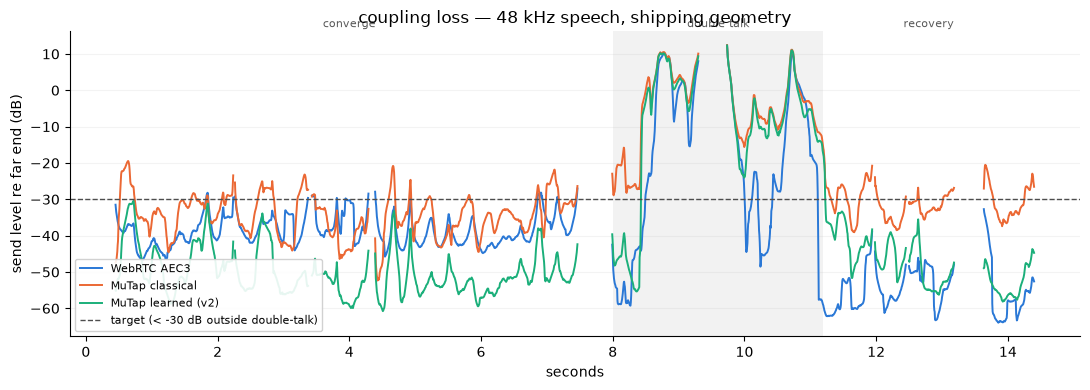

In [6]:
import statistics as _st
SY48 = [("WebRTC AEC3", "#2a78d6",
         lambda: webrtc_aec3.WebRtcAec3(AEC3_BIN, rate=48000)),
        ("MuTap classical", "#eb6834",
         lambda: mutap_ffi.AecChain(lib, 256, 8, 48000.0)),
        ("MuTap learned (v2)", "#1baf7a",
         lambda: mutap_ffi.AecChain(lib, 256, 8, 48000.0, nn_weights=str(V2_WEIGHTS)))]
if not HAVE_AEC3:
    SY48 = SY48[1:]

if HAVE_SPEECH:
    scen48 = SCEN / "speech48"
    if len(list(scen48.glob("*/manifest.json"))) < 3:
        _run([sys.executable, REPO / "tools/ml/make_dataset.py", "--corpus", LIBRI,
              "--scenarios", scen48, "--examples", "3", "--seed", "7",
              "--rate", "48000", "--build-dir", BUILD])
    scns48 = [metrics.Scenario.load(q.parent) for q in sorted(scen48.glob("*/manifest.json"))]
    res48 = []
    for scn in scns48:
        row = {}
        for name, color, make in SY48:
            e = make().process(scn.x, scn.y)
            row[name] = (e, metrics.measure(scn, e), color)
        res48.append(row)
    plot_tclw(scns48[0], res48[0],
              "coupling loss — 48 kHz speech, shipping geometry", fs=48000)

    hdr = f"{'system':>20} | {'stERLE':>7} | {'dtSUP':>6} | {'recERLE':>7} | {'neSDR':>6}"
    print("48 kHz speech (medians over 3):"); print(hdr); print("-" * len(hdr))
    for name, _, _ in SY48:
        med = {k: _st.median(r[name][1].as_dict()[k] for r in res48)
               for k in ("st_erle_db", "dt_suppression_db", "rec_erle_db", "ne_sdr_db")}
        print(f"{name:>20} | {med['st_erle_db']:7.1f} | {med['dt_suppression_db']:6.1f} | "
              f"{med['rec_erle_db']:7.1f} | {med['ne_sdr_db']:6.1f}")
else:
    print("speech corpus absent — 48 kHz section skipped")

The v2 numbers close most of the case Part 1 opened. On speech
at the shipping geometry the learned engine leads classical by ~19 dB
of single-talk ERLE and ~20 dB of recovery ERLE, at *better* near-end
transparency, with double-talk suppression within ~1.5 dB. And the
off-domain weakness shrank from a collapse to a gap: on music
double-talk (measured separately with the same meter —
`tools/ml/README.md`), v2 holds 4 dB of suppression at
better-than-classical transparency where v1 held none; classical still
leads there with 9 dB. AEC3 at 48 kHz repeats its Part 1 shape:
competitive echo removal, single-digit talker SDR.

## Verdict

- **Echo removal** is not the differentiator — every system removes
  echo well while only echo is present. The differentiators are what
  happens when a talker shares the room, and what the system does to
  material it has never seen.
- **MuTap classical** is the only engine whose double-talk suppression
  and talker fidelity hold for *arbitrary* material, at both
  geometries. It stays `mutap.aec~`'s certified default
  (`@postfilter 1`).
- **MuTap learned** is the measured case for shipping a second engine:
  v2 at the native geometry wins single-talk and recovery ERLE by
  ~20 dB at equal-or-better transparency, gives up ~1.5 dB of speech
  double-talk, and degrades *gracefully* off-domain (bounded band
  gains on the canceller's output — coloration, never deletion). Its
  remaining off-domain double-talk gap is a data/feature problem with
  a filed fix (the coherence feature), not a design commitment.
- **DTLN-aec** shows both faces of end-to-end: best-in-field speech
  ERLE, and out-of-domain talkers deleted outright at 200x the
  learned engine's parameter count — with weights that cannot be
  shipped under a clean license.
- **WebRTC AEC3** is the telephony datapoint: effective, deployed,
  and ducking every talker to single-digit SDR by design — the
  opposite of the right trade for program material.